# Part 1

We import the `logins.json` file and create a timeseries visualization of logins at the given geographical location.

In [1]:
%matplotlib inline
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import datetime
from dateutil.relativedelta import relativedelta
import seaborn as sns
import statsmodels.api as sm
from statsmodels.tsa.stattools import acf
from statsmodels.tsa.stattools import pacf
from statsmodels.tsa.seasonal import seasonal_decompose

In [2]:
df = pd.read_json('logins.json')

## Initial EDA

In [3]:
df.head()

,login_time
0,1970-01-01 20:13:18
1,1970-01-01 20:16:10
2,1970-01-01 20:16:37
3,1970-01-01 20:16:36
4,1970-01-01 20:26:21


In [4]:
df.describe()

,login_time
count,93142
mean,1970-02-26 19:09:39.779648278
min,1970-01-01 20:12:16
25%,1970-02-04 10:37:19.750000
50%,1970-03-01 06:33:05.500000
75%,1970-03-22 04:01:10.750000
max,1970-04-13 18:57:38


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 93142 entries, 0 to 93141
Data columns (total 1 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   login_time  93142 non-null  datetime64[ns]
dtypes: datetime64[ns](1)
memory usage: 727.8 KB


<Axes: title={'center': 'Logins'}>

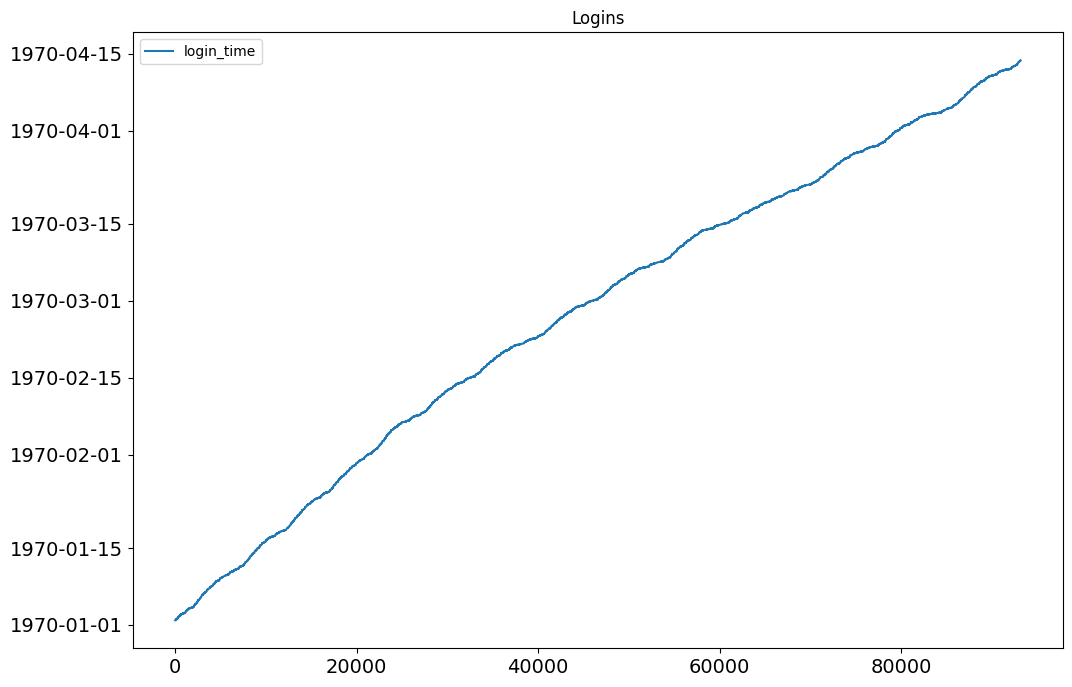

In [6]:
df.plot(figsize=(12,8), title='Logins', fontsize=14)

The data appears to be solid. There were no null values and there were a significant number of entries.

The data increases linearly in terms of time. There are a few light patterns visible in the line.

## Breaking into 15-Minute Intervals

Let's break the data into varying types of fifteen-minute increments.

In [7]:
df['15min_inc'] = df['login_time'].dt.floor('15min')

In [9]:
df['month'] = df['login_time'].dt.month

In [10]:
df['day_name'] = df['login_time'].dt.day_name()

In [14]:
df['15min_as_str'] = df['15min_inc'].dt.time.apply(lambda x: x.strftime('%H:%M'))

In [15]:
df.head(2)

,login_time,15min_inc,month,day_name,time_15_min_inc,15min_as_str
0,1970-01-01 20:13:18,1970-01-01 20:00:00,1,Thursday,20:00,20:00
1,1970-01-01 20:16:10,1970-01-01 20:15:00,1,Thursday,20:15,20:15


### Basic 15-Minute Intervals

In [16]:
counts_15min = df['15min_as_str'].value_counts().sort_index()

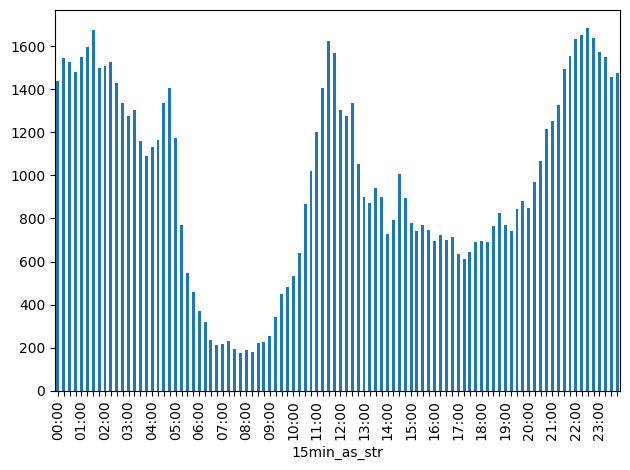

In [26]:
ax = counts_15min.plot.bar()
n = 4
for index, label in enumerate(ax.get_xticklabels()):
    if index % n != 0:
        label.set_visible(False)

plt.tight_layout()
plt.show()

### Day of the Week and 15-Min Incremenets

In [ ]:
df['day_15min'] = df['